# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
#xem 5 dòng đầu tiên
display(df.head())
#xem 5 dòng cuối cùng
display(df.tail())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [9]:
# TODO
#data size (xem cột và hàng) dùng shape
print("data size:", df.shape)


data size: (541909, 8)


In [10]:
#dùng info cũng được
df.info


<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [11]:
#columns names
print("columns names: ",df.columns)

columns names:  Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [12]:
#data types
print("data types:", df.dtypes)

data types: InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## A.2. Missing values & Duplicate data

In [13]:
# TODO
#missing values(giá trị bị thiếu) dùng ínull
df.isnull().sum()



InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
#duplicate data(dữ liệu bị trùng lắp)
print("sum dữ liệu bị trùng lắp:", df.duplicated().sum())
#điếm 
print("count duplicate data: ",df.duplicated().sum())

sum dữ liệu bị trùng lắp: 5268
count duplicate data:  5268


## A.3. Invalid values

In [15]:
# TODO
#invalid values(giá trị không hợp lệ)
df['StockCode'].unique()




array(['85123A', '71053', '84406B', ..., '90214U', '47591b', '23843'],
      shape=(4070,), dtype=object)

## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [16]:
# TODO
df[(df['Quantity'] <= 0) & (df['UnitPrice'] <= 0) ]




,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [18]:
# Mean
df['Quantity'].mean()

# Median
df['Quantity'].median()

# Mode
df['Quantity'].mode()

0    1
Name: Quantity, dtype: int64

## Group 2 — Dispersion

In [21]:
# TODO
print(df['Quantity'].max() - df['Quantity'].min())

161990


In [22]:
#phương sai(var)
print(df['Quantity'].var())

47559.391409298616


In [23]:
#độ lệch chuẩn(std)
print(df['Quantity'].std())

218.08115785023386


## Group 3 — Location and Shape

In [24]:
# TODO
#vị trí(location) skew() chọn độ lệch
print("skew: ", df['Quantity'].skew())


skew:  -0.2640763070669525


In [25]:
#độ chọn, kurt()
print("kurt: ", df['Quantity'].kurt())


kurt:  119769.1600306859


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [26]:
# TODO
# Tạo cột doanh thu
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Chỉ lấy các giao dịch hợp lệ
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Doanh thu theo quốc gia
country_revenue = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Quốc gia doanh thu cao nhất
top_country = country_revenue.idxmax()
top_revenue = country_revenue.max()

# Tính tỷ lệ %
percent = top_revenue / country_revenue.sum() * 100

print(f"Quốc gia doanh thu cao nhất: {top_country}")
print(f"Doanh thu: {top_revenue:,.2f}")
print(f"Tỷ lệ: {percent:.2f}%")

Quốc gia doanh thu cao nhất: United Kingdom
Doanh thu: 9,025,222.08
Tỷ lệ: 84.61%


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [34]:
# Tạo cột doanh thu
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Lọc giao dịch hợp lệ
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Tính doanh thu theo sản phẩm
product_revenue = df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

# Xem sản phẩm có doanh thu cao nhất
print("Sản phẩm bán chạy nhất:", product_revenue.index[0])
print("Doanh thu:", product_revenue.iloc[0])

Sản phẩm bán chạy nhất: DOTCOM POSTAGE
Doanh thu: 206248.77


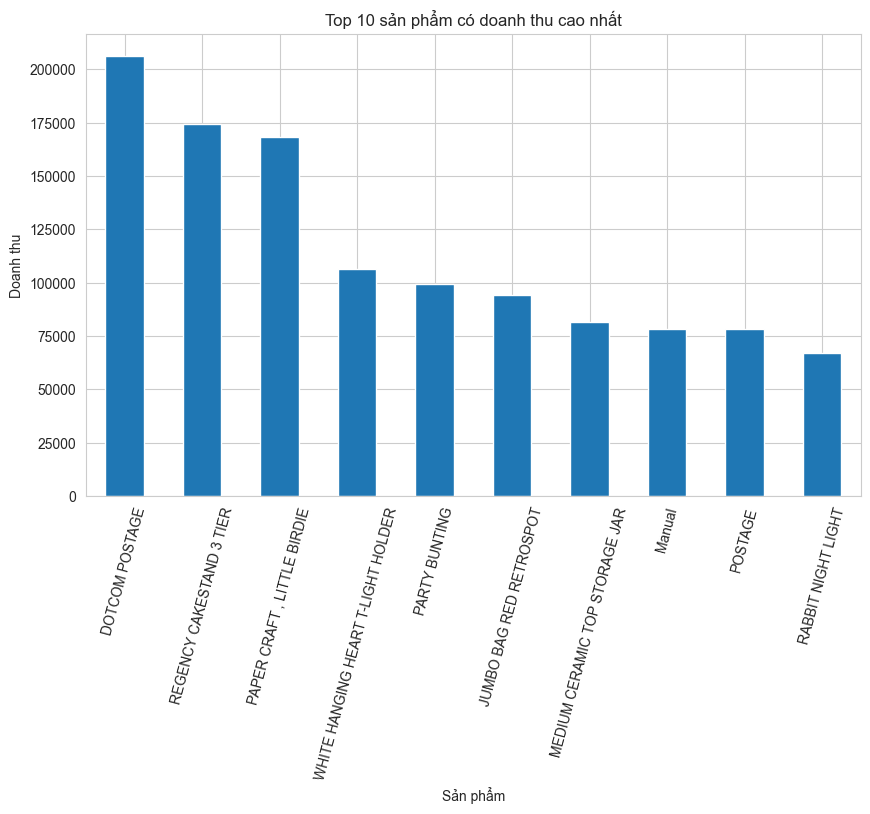

In [ ]:
# TODO biểu đồ cột
plt.figure(figsize=(10,6))

product_revenue.head(10).plot(kind='bar')

plt.title('Top 10 sản phẩm có doanh thu cao nhất')
plt.xlabel('Sản phẩm')
plt.ylabel('Doanh thu')
plt.xticks(rotation=75)

plt.show()

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [28]:
# TODO
# Tạo cột doanh thu
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Chỉ lấy giao dịch hợp lệ
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Doanh thu theo tháng
monthly_revenue = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
)

# Chuyển Period sang Timestamp để vẽ
monthly_revenue.index = monthly_revenue.index.to_timestamp()


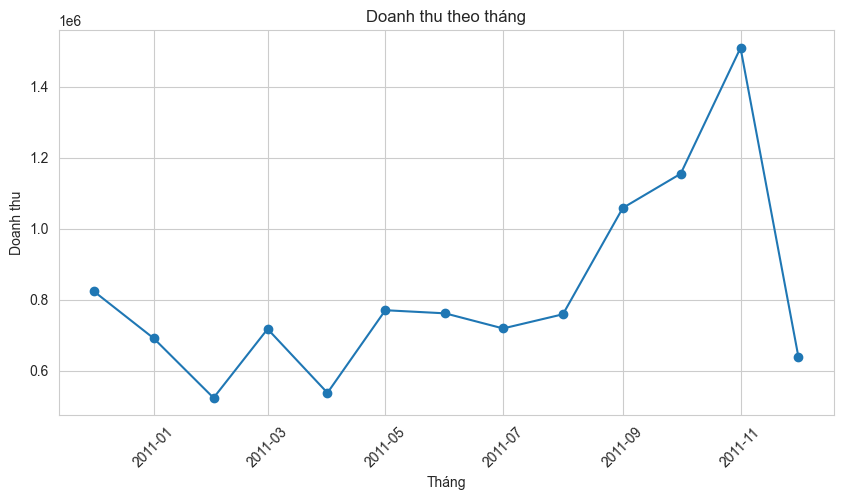

In [29]:
# Vẽ biểu đồ
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Doanh thu theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu')
plt.xticks(rotation=45)
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [30]:
# TODO
# Tạo cột doanh thu
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Chỉ lấy giao dịch hợp lệ
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Tính giá trị của từng đơn hàng
order_value = (
    df_sales.groupby(['Country', 'InvoiceNo'])['Revenue']
    .sum()
    .reset_index()
)

# Tính Average Order Value theo quốc gia
aov = (
    order_value.groupby('Country')['Revenue']
    .mean()
    .sort_values(ascending=False)
)

print(aov)

Country
Singapore               3039.898571
Netherlands             3036.663191
Australia               2430.198421
Japan                   1969.282632
Lebanon                 1693.880000
Hong Kong               1426.527273
Brazil                  1143.600000
Sweden                  1066.064722
Switzerland             1057.220370
Denmark                 1053.074444
Israel                  1016.907500
Norway                  1004.595556
RSA                     1002.310000
EIRE                     984.215139
Greece                   952.104000
Cyprus                   849.398750
Channel Islands          786.555385
USA                      716.078000
Spain                    684.190111
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 581.846552
Finland                  549.904390
Malta                    545.118000
France                   534.987526
United Kingdom      

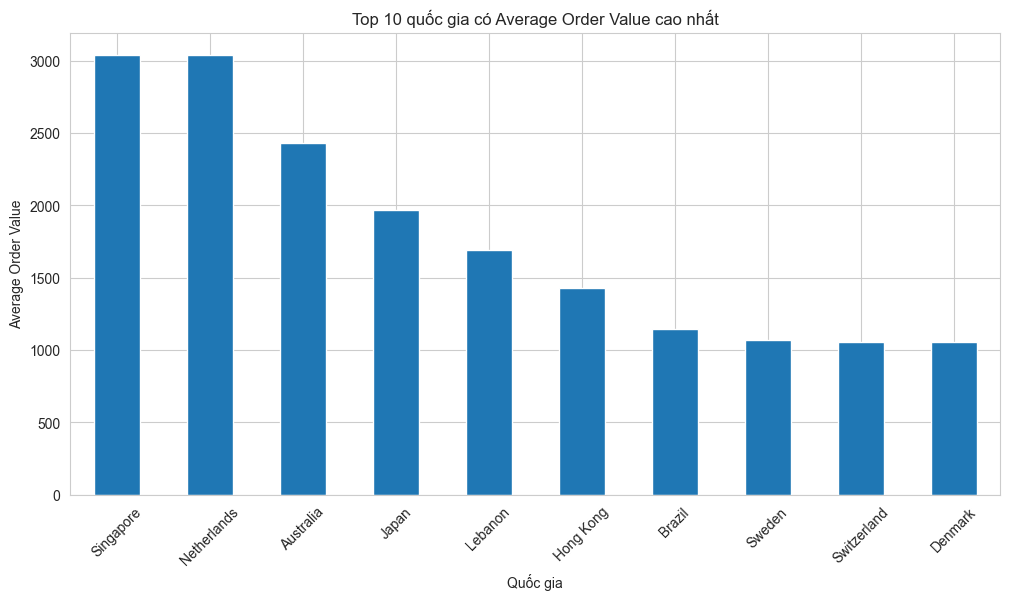

In [31]:
plt.figure(figsize=(12,6))

aov.head(10).plot(kind='bar')

plt.title('Top 10 quốc gia có Average Order Value cao nhất')
plt.xlabel('Quốc gia')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)

plt.show()

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [32]:
# TODO
# Xác định giao dịch trả hàng/hủy
df['IsReturn'] = df['Quantity'] < 0

# Tính tỷ lệ trả hàng theo quốc gia
return_rate = (
    df.groupby('Country')['IsReturn']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(return_rate)

Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.877681
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.770932
EIRE                     3.684724
Poland                   3.225806
Singapore                3.056769
Sweden                   2.380952
Denmark                  2.313625
Spain                    1.894986
United Kingdom           1.855178
Belgium                  1.836636
Switzerland              1.748252
France                   1.741264
European Community       1.639344
Finland                  1.438849
Hong Kong                1.388889
Channel Islands          1.319261
Norway                   1.289134
Cyprus                   1.286174
Portugal                 1.184990
Austria                  0.748130
Greece                   0.684932
Israel                   0.673401
Nether

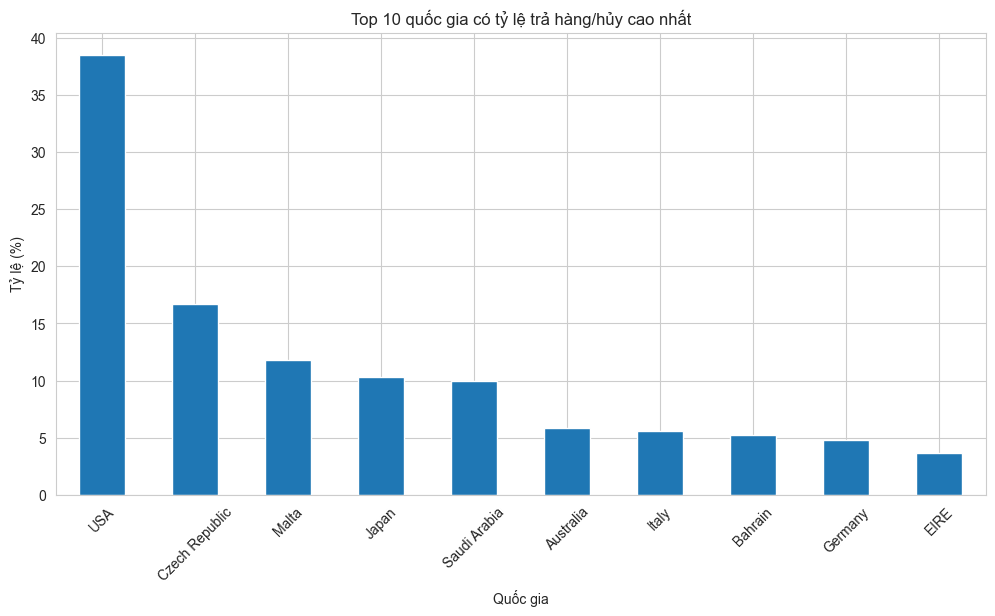

In [33]:
plt.figure(figsize=(12,6))

return_rate.head(10).plot(kind='bar')

plt.title('Top 10 quốc gia có tỷ lệ trả hàng/hủy cao nhất')
plt.xlabel('Quốc gia')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=45)

plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*(Viết insight của bạn vào đây...)*
Dữ liệu có một số giá trị thiếu, trùng và không hợp lệ cần được làm sạch.
Số lượng sản phẩm trong các giao dịch có sự chênh lệch khá lớn.
United Kingdom là quốc gia có doanh thu cao nhất.
Doanh thu thay đổi theo từng tháng và giá trị đơn hàng trung bình khác nhau giữa các quốc gia.
Tỷ lệ trả hàng/hủy đơn cũng có sự khác nhau giữa các quốc gia.